In [22]:
import sys
import os

# Adding project root to Python path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added:", project_root)

Project root added: /home/ubuntu/VisionSAE_Interpreting-Visual-Representations


# LOAD CSV

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../results_summary.csv")

# LOAD CONFIG

In [20]:
import yaml
cfg = yaml.safe_load(open("../configs/vit_base_cifar.yaml"))
device = cfg["training"]["device"]

# LOAD BACKBONE

In [23]:
import torch
from models.backbone import VisionBackbone

backbone = VisionBackbone(
    cfg["model"]["backbone"],
    cfg["model"]["pretrained"]
).to(device)

backbone.eval()

VisionBackbone(
  (model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          

# LOAD SAE CHECKPOINT

In [24]:
from models.sae import SparseAutoencoder

layer_idx = 5
width = 8192
seed = 42

# Load one feature file to infer input_dim
features = torch.load(f"../features/layer_{layer_idx}.pt")
input_dim = features.shape[-1]

sae = SparseAutoencoder(
    input_dim,
    width,
    cfg["sae"]["sparsity"],
    cfg["sae"]["topk"]
).to(device)

ckpt_path = f"../checkpoints/layer_{layer_idx}_width_{width}_seed_{seed}.pt"
sae.load_state_dict(torch.load(ckpt_path, weights_only=True))
sae.eval()

SparseAutoencoder(
  (encoder): Linear(in_features=768, out_features=8192, bias=False)
  (decoder): Linear(in_features=8192, out_features=768, bias=False)
)

# CREATE DATA LOADER

In [25]:
from data.datamodule import get_dataloader

dataloader = get_dataloader(cfg)

100%|██████████| 170M/170M [01:33<00:00, 1.81MB/s] 
/home/ubuntu/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# PATCH VISUALIZATION

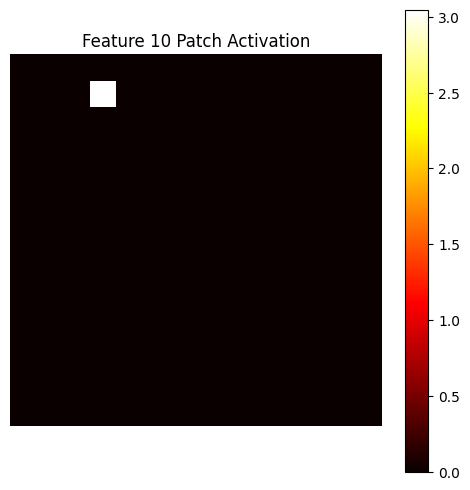

In [27]:
from analysis.patch_interpretability import visualize_patch_activation

images, _ = next(iter(dataloader))

visualize_patch_activation(
    sae,
    backbone,
    images[0],
    feature_idx=10,
    layer_idx=layer_idx,
    device=device
)

# SPARSITY VS DEPTH

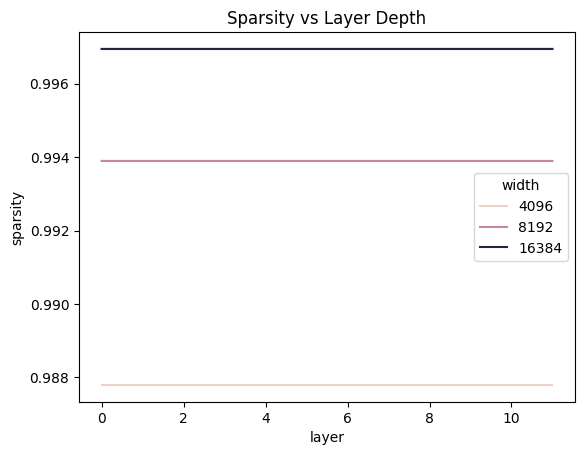

In [18]:
sns.lineplot(data=df, x="layer", y="sparsity", hue="width")
plt.title("Sparsity vs Layer Depth")
plt.show()

# CROSS-WIDTH ALIGNMENT

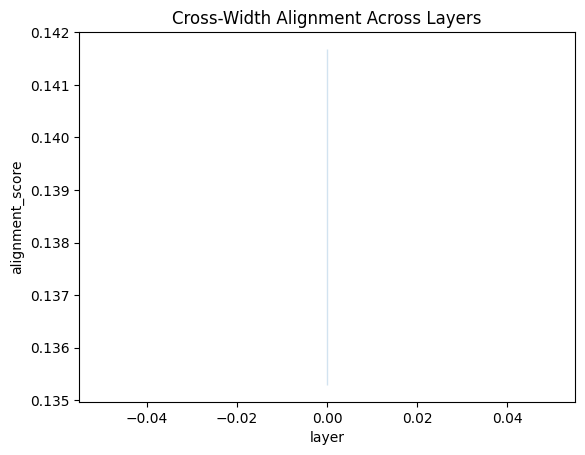

In [15]:
cw = pd.read_csv("../cross_width_summary.csv")

sns.lineplot(data=cw, x="layer", y="alignment_score")
plt.title("Cross-Width Alignment Across Layers")
plt.show()

# STABILITY VS WIDTH

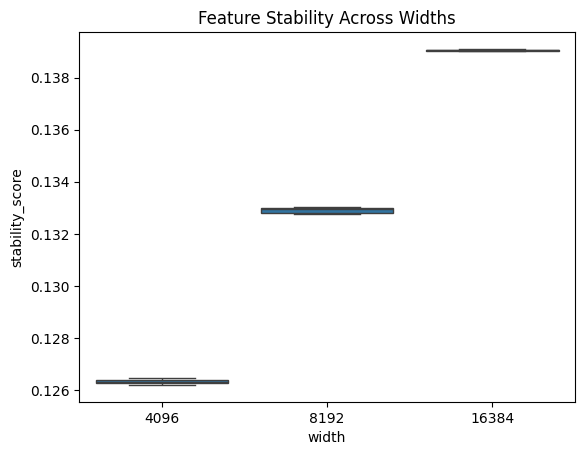

In [13]:
stab = pd.read_csv("../stability_summary.csv")

sns.boxplot(data=stab, x="width", y="stability_score")
plt.title("Feature Stability Across Widths")
plt.show()